# Clasificación: Predicción de Pit Stop en Fórmula 1
1. Carga de datos preparados
2. Validación Cruzada con el 70%
3. Modelos Supervisados Base (4 métodos)
4. Métodos de Ensamble (4 métodos)
5. Tabla comparativa de medidas de calidad
6. Selección estadística: ANOVA + Tukey
7. Hiperparametrización del Top 3 (GridSearch + Optimización Bayesiana)
8. Guardamos el modelo final

In [1]:
# Importamos librerías básicas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
import warnings
warnings.filterwarnings('ignore')

# 1. Carga de datos preparados

In [2]:
# Cargamos los datos preparados desde el Notebook 1
(
    X_train, X_train_norm,
    X_test,  X_test_norm,
    Y_train, Y_test,
    min_max_scaler, compound_map, variables
) = pickle.load(open('datos_preparados.pkl', 'rb'))

print(f'Train (sin normalizar): {X_train.shape}')
print(f'Test  (sin normalizar): {X_test.shape}')
print(f'Y_train distribución: {pd.Series(Y_train).value_counts().to_dict()}')
print(f'Y_test distribución : {pd.Series(Y_test).value_counts().to_dict()}')

Train (sin normalizar): (105758, 10)
Test  (sin normalizar): (30412, 10)
Y_train distribución: {0: 52879, 1: 52879}
Y_test distribución : {0: 22663, 1: 7749}


In [3]:
# DataFrame para comparar resultados de todos los modelos
from sklearn import metrics

medidas = pd.DataFrame(index=['accuracy','precision','recall','f1','roc_auc'])

# 2. Validación Cruzada (sobre el 70%)

In [4]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

# Configuramos la validación cruzada con 10 folds estratificados
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Diccionario para guardar scores CV de cada modelo (para ANOVA)
cv_scores = {}

def evaluar_modelo(nombre, modelo, X_tr, X_te, Y_tr, Y_te):
    """Entrena, evalúa y guarda métricas de un modelo."""
    # Validación cruzada en el 70%
    cv = cross_val_score(modelo, X_tr, Y_tr, cv=skf, scoring='roc_auc', n_jobs=-1)
    cv_scores[nombre] = cv
    print(f'  CV ROC-AUC: {cv.mean():.4f} ± {cv.std():.4f}')

    # Entrenamiento en 70% y evaluación en 30%
    modelo.fit(X_tr, Y_tr)
    Y_pred  = modelo.predict(X_te)
    Y_proba = modelo.predict_proba(X_te)[:, 1]

    acc  = metrics.accuracy_score(Y_te, Y_pred)
    prec = metrics.precision_score(Y_te, Y_pred, zero_division=0)
    rec  = metrics.recall_score(Y_te, Y_pred, zero_division=0)
    f1   = metrics.f1_score(Y_te, Y_pred, zero_division=0)
    auc  = metrics.roc_auc_score(Y_te, Y_proba)

    medidas[nombre] = [acc, prec, rec, f1, auc]

    # Matriz de confusión
    cm = metrics.confusion_matrix(Y_te, Y_pred)
    disp = metrics.ConfusionMatrixDisplay(cm, display_labels=['No Pit','Pit'])
    disp.plot(cmap='Blues')
    plt.title(f'Matriz de Confusión - {nombre}')
    plt.show()

    # Gráfica de la curva ROC
    fpr, tpr, _ = metrics.roc_curve(Y_te, Y_proba)
    plt.plot(fpr, tpr, label=f'{nombre} (AUC={auc:.3f})')
    plt.plot([0,1],[0,1],'k--')
    plt.xlabel('FPR'); plt.ylabel('TPR')
    plt.title(f'Curva ROC - {nombre}')
    plt.legend()
    plt.show()

    return modelo

print('Función de evaluación configurada ')

Función de evaluación configurada 


# 3. Modelos Supervisados Base
## 3.1 Árbol de Decisión
- No se normaliza

Árbol de Decisión:
  CV ROC-AUC: 0.9101 ± 0.0022


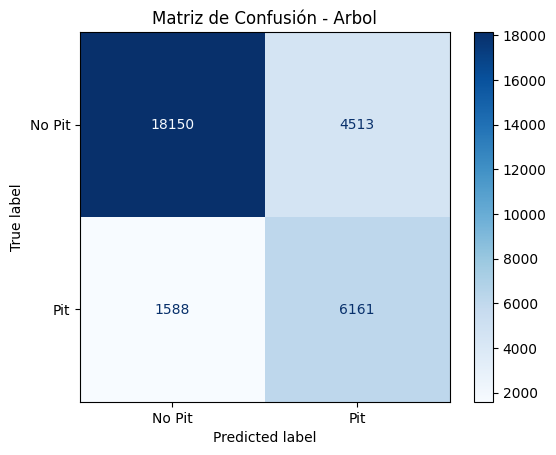

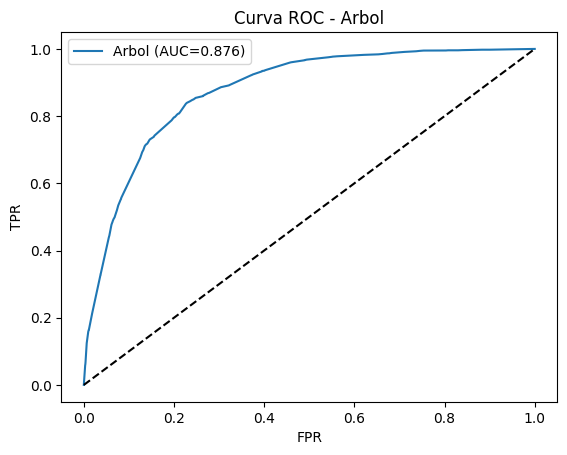

In [5]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

model_Tree = DecisionTreeClassifier(
    criterion='gini',
    max_depth=10,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42
)

print('Árbol de Decisión:')
model_Tree = evaluar_modelo('Arbol', model_Tree, X_train, X_test, Y_train, Y_test)

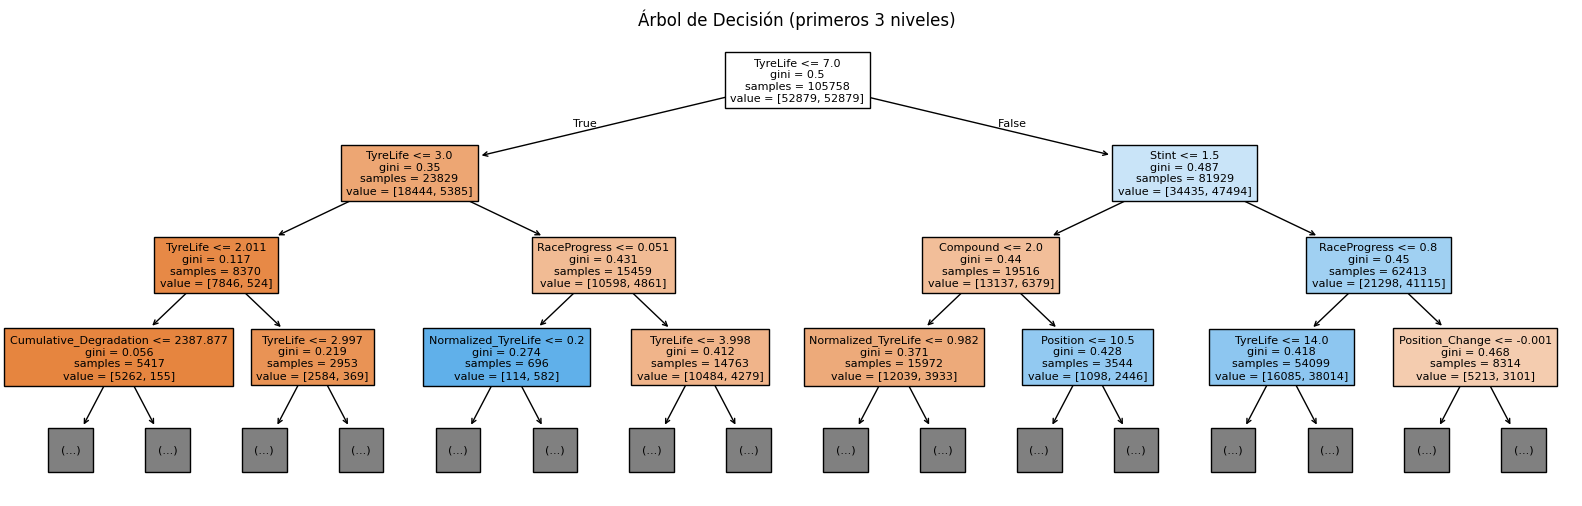

In [6]:
# Graficar el árbol (primeros niveles)
plt.figure(figsize=(20, 6))
plot_tree(model_Tree, feature_names=variables, filled=True, max_depth=3, fontsize=8)
plt.title('Árbol de Decisión (primeros 3 niveles)')
plt.show()

In [7]:
medidas

,Arbol
accuracy,0.799388
precision,0.577197
recall,0.795070
f1,0.668838
roc_auc,0.876478


## 3.2 KNN
- Se normaliza

KNN:
  CV ROC-AUC: 0.9692 ± 0.0015


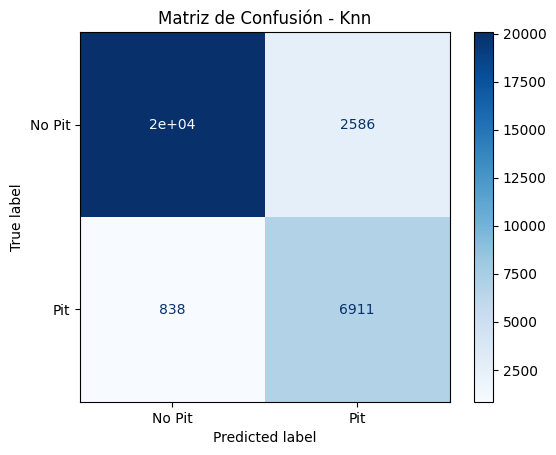

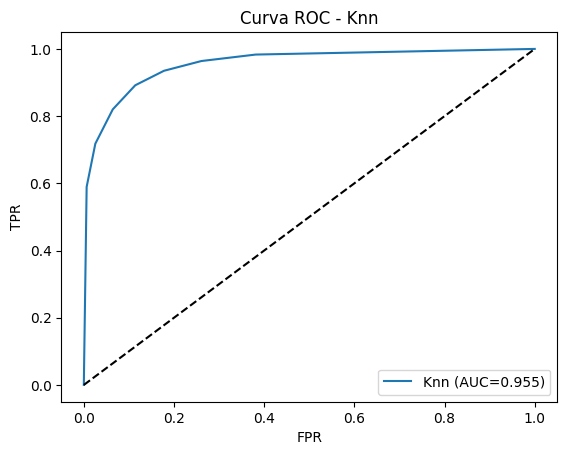

In [8]:
from sklearn.neighbors import KNeighborsClassifier

model_Knn = KNeighborsClassifier(n_neighbors=7, metric='euclidean')

# Handle NaN values in X_train_norm and X_test_norm
# Impute using the mean of the training set to prevent data leakage
mean_imputation_values = X_train_norm.mean()
X_train_norm_imputed = X_train_norm.fillna(mean_imputation_values)
X_test_norm_imputed = X_test_norm.fillna(mean_imputation_values)

print('KNN:')
model_Knn = evaluar_modelo('Knn', model_Knn, X_train_norm_imputed, X_test_norm_imputed, Y_train, Y_test)

In [9]:
medidas

,Arbol,Knn
accuracy,0.799388,0.887413
precision,0.577197,0.727703
recall,0.795070,0.891857
f1,0.668838,0.801461
roc_auc,0.876478,0.954716


## 3.3 Red Neuronal (MLP)
- Se normaliza

Red Neuronal (MLP):
  CV ROC-AUC: 0.9211 ± 0.0081


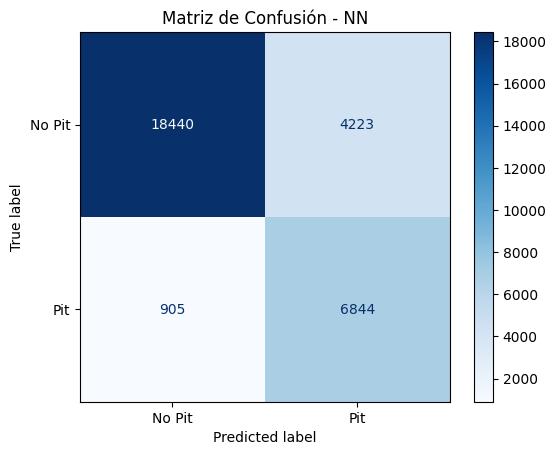

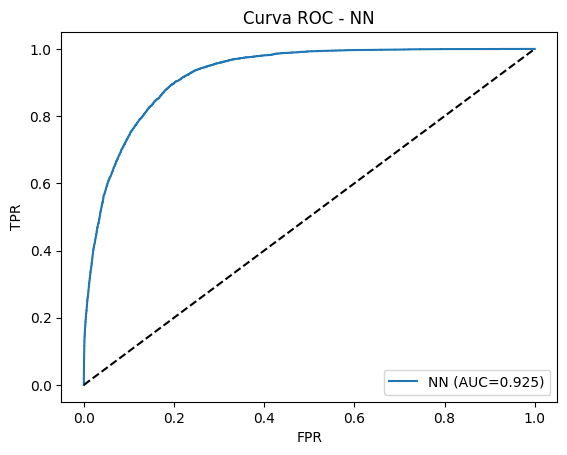

In [10]:
from sklearn.neural_network import MLPClassifier

model_NN = MLPClassifier(
    activation='relu',
    hidden_layer_sizes=(70, 44),
    learning_rate='adaptive',
    learning_rate_init=0.001,
    momentum=0.9,
    max_iter=300,
    early_stopping=True,
    random_state=42
)

print('Red Neuronal (MLP):')
model_NN = evaluar_modelo('NN', model_NN, X_train_norm_imputed, X_test_norm_imputed, Y_train, Y_test)

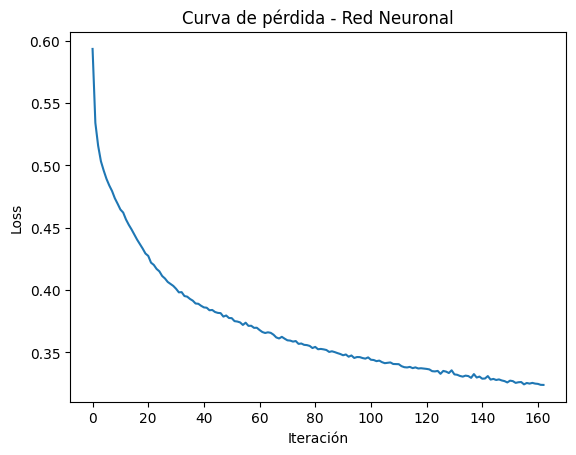

In [11]:
# Curva de pérdida de la red neuronal
plt.plot(model_NN.loss_curve_)
plt.title('Curva de pérdida - Red Neuronal')
plt.xlabel('Iteración'); plt.ylabel('Loss')
plt.show()

In [12]:
medidas

,Arbol,Knn,NN
accuracy,0.799388,0.887413,0.831382
precision,0.577197,0.727703,0.618415
recall,0.795070,0.891857,0.883211
f1,0.668838,0.801461,0.727466
roc_auc,0.876478,0.954716,0.925008


## 3.4 SVM
- Se normaliza

SVM:
  CV ROC-AUC: 0.5619 ± 0.0607


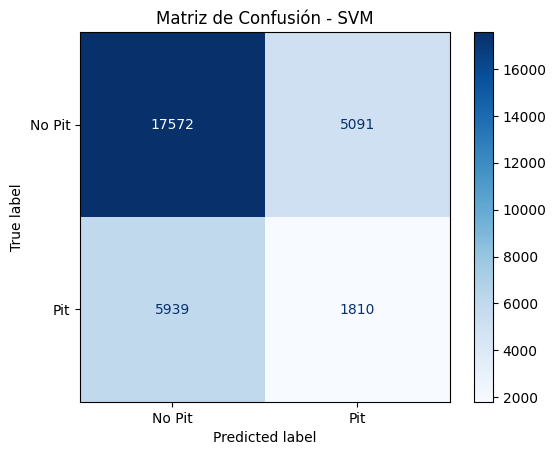

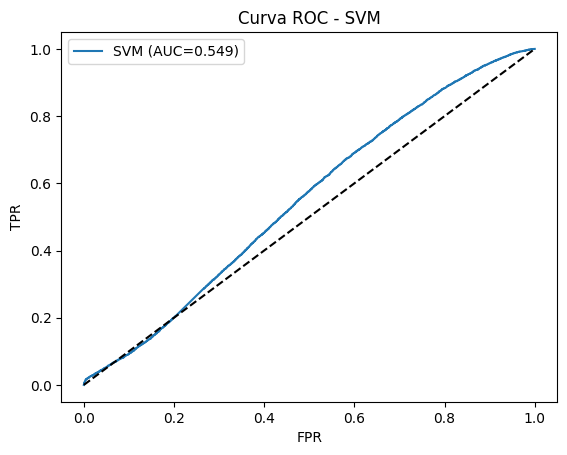

In [13]:
from sklearn.svm import SVC

model_svm = SVC(
    kernel='linear',
    C=1.0,
    class_weight='balanced',
    random_state=42,
    probability=True,
    max_iter=100
)
print('SVM:')
model_svm = evaluar_modelo('SVM', model_svm, X_train_norm_imputed, X_test_norm_imputed, Y_train, Y_test)

In [14]:
medidas

,Arbol,Knn,NN,SVM
accuracy,0.799388,0.887413,0.831382,0.637314
precision,0.577197,0.727703,0.618415,0.262281
recall,0.795070,0.891857,0.883211,0.233579
f1,0.668838,0.801461,0.727466,0.247099
roc_auc,0.876478,0.954716,0.925008,0.548532


SGDClassifier (simil-SVM):
  CV ROC-AUC: 0.7390 ± 0.0036


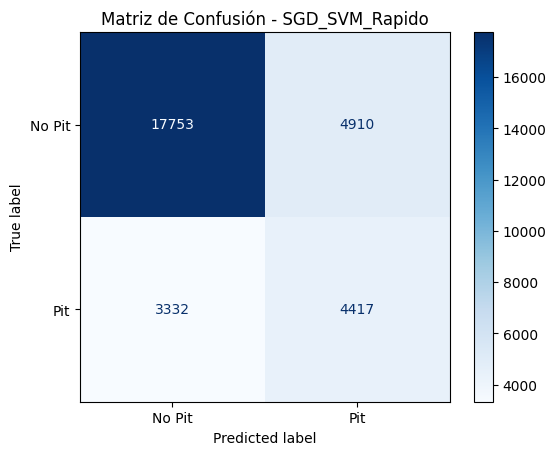

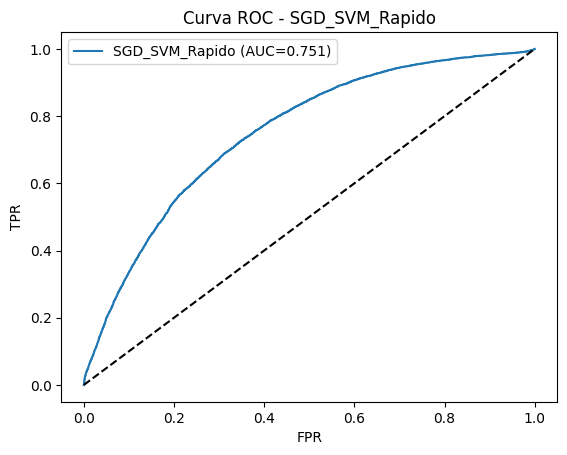

In [15]:
from sklearn.linear_model import SGDClassifier

# Configuración para un SVM lineal más rápido usando SGDClassifier
model_SGD_SVM = SGDClassifier(
    loss='log_loss',         # Utiliza pérdida logística para estimar probabilidades (similar a SVC)
    alpha=0.0001,            # Parámetro de regularización (ajustable)
    max_iter=1000,           # Número de iteraciones (puede necesitar ajuste)
    tol=1e-3,                # Criterio de parada
    class_weight='balanced', # Para manejar desequilibrio de clases
    random_state=42,
    early_stopping=True,     # Detener si no hay mejora para acelerar la convergencia
    n_iter_no_change=5       # Número de épocas sin mejora para parar
)

print('SGDClassifier (simil-SVM):')
# Para usarlo, deberías llamar a evaluar_modelo con este nuevo modelo:
model_SGD_SVM = evaluar_modelo('SGD_SVM_Rapido', model_SGD_SVM, X_train_norm_imputed, X_test_norm_imputed, Y_train, Y_test)

In [16]:
medidas

,Arbol,Knn,NN,SVM,SGD_SVM_Rapido
accuracy,0.799388,0.887413,0.831382,0.637314,0.728989
precision,0.577197,0.727703,0.618415,0.262281,0.473571
recall,0.795070,0.891857,0.883211,0.233579,0.570009
f1,0.668838,0.801461,0.727466,0.247099,0.517334
roc_auc,0.876478,0.954716,0.925008,0.548532,0.750648


# 4. Métodos de Ensamble
## 4.1 Random Forest
- No se normaliza

Random Forest:
  CV ROC-AUC: 0.9751 ± 0.0013


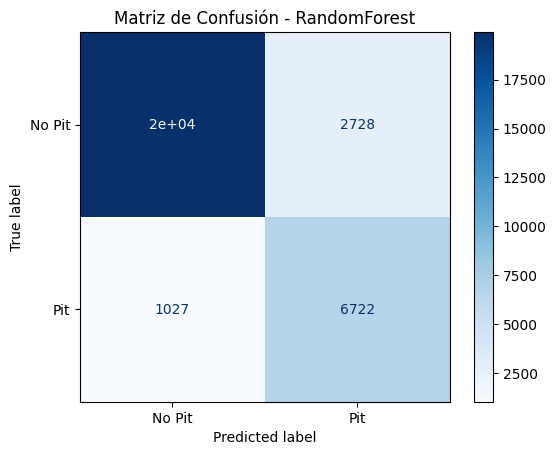

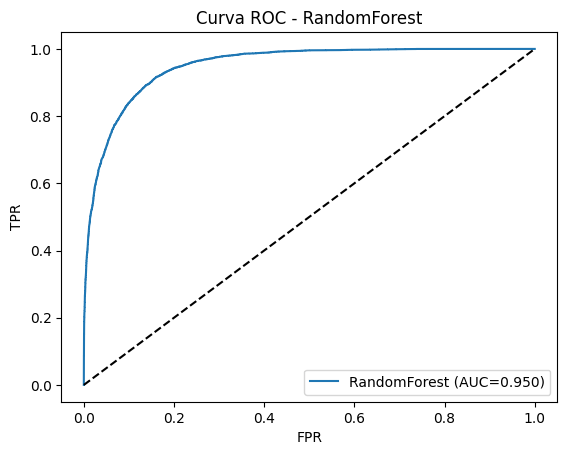

In [17]:
from sklearn.ensemble import RandomForestClassifier

model_RF = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

print('Random Forest:')
model_RF = evaluar_modelo('RandomForest', model_RF, X_train, X_test, Y_train, Y_test)

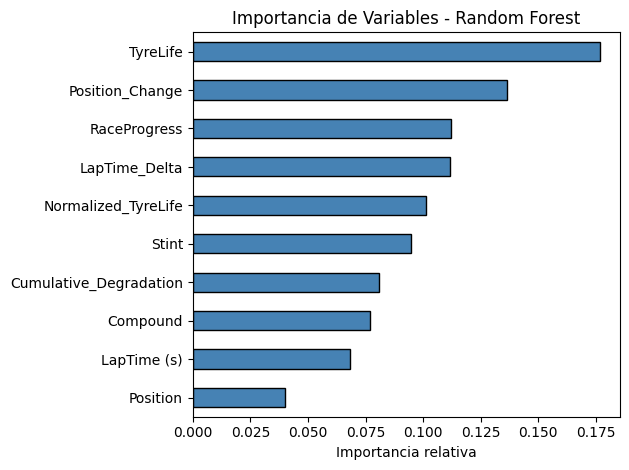

In [18]:
# Importancia de variables del Random Forest
importancias = pd.Series(model_RF.feature_importances_, index=variables).sort_values(ascending=True)
importancias.plot(kind='barh', color='steelblue', edgecolor='black')
plt.title('Importancia de Variables - Random Forest')
plt.xlabel('Importancia relativa')
plt.tight_layout()
plt.show()

In [19]:
medidas

,Arbol,Knn,NN,SVM,SGD_SVM_Rapido,RandomForest
accuracy,0.799388,0.887413,0.831382,0.637314,0.728989,0.876529
precision,0.577197,0.727703,0.618415,0.262281,0.473571,0.711323
recall,0.795070,0.891857,0.883211,0.233579,0.570009,0.867467
f1,0.668838,0.801461,0.727466,0.247099,0.517334,0.781673
roc_auc,0.876478,0.954716,0.925008,0.548532,0.750648,0.949870


## 4.2 Gradient Boosting
- No se normaliza

Gradient Boosting:
  CV ROC-AUC: 0.9561 ± 0.0016


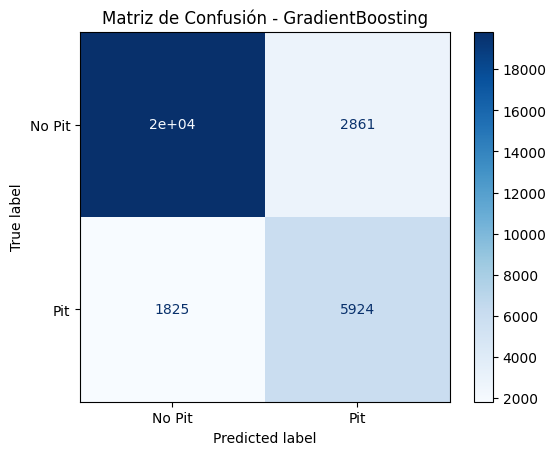

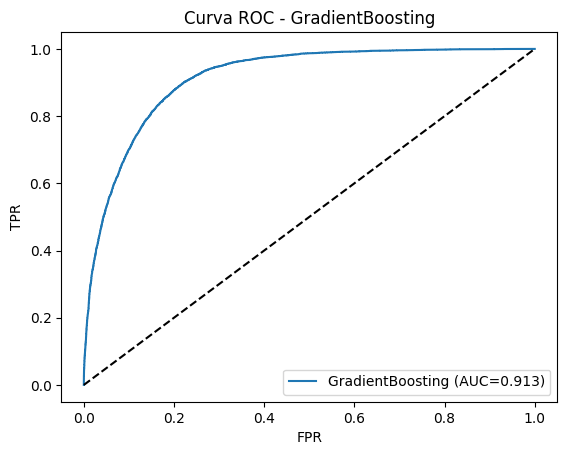

In [20]:
from sklearn.ensemble import GradientBoostingClassifier

model_GB = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)

print('Gradient Boosting:')
model_GB = evaluar_modelo('GradientBoosting', model_GB, X_train_norm_imputed, X_test_norm_imputed, Y_train, Y_test)

In [21]:
medidas

,Arbol,Knn,NN,SVM,SGD_SVM_Rapido,RandomForest,GradientBoosting
accuracy,0.799388,0.887413,0.831382,0.637314,0.728989,0.876529,0.845916
precision,0.577197,0.727703,0.618415,0.262281,0.473571,0.711323,0.674331
recall,0.795070,0.891857,0.883211,0.233579,0.570009,0.867467,0.764486
f1,0.668838,0.801461,0.727466,0.247099,0.517334,0.781673,0.716584
roc_auc,0.876478,0.954716,0.925008,0.548532,0.750648,0.949870,0.913385


## 4.3 Bagging
- No se normaliza

Bagging (base: Árbol de Decisión):
  CV ROC-AUC: 0.9028 ± 0.0028


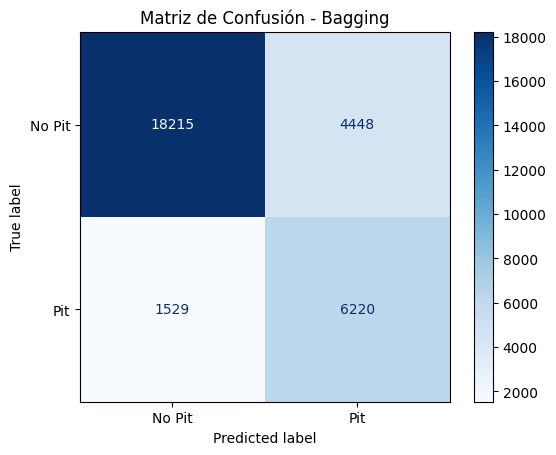

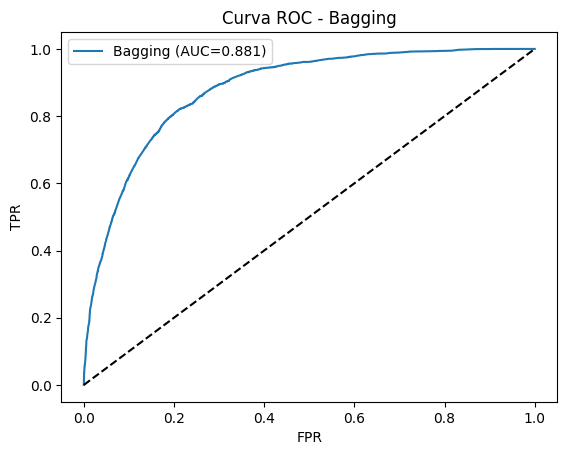

In [22]:
from sklearn.ensemble import BaggingClassifier

model_Bag = BaggingClassifier(
    estimator=DecisionTreeClassifier(max_depth=8, class_weight='balanced'),
    n_estimators=50,
    random_state=42,
    n_jobs=-1
)

print('Bagging (base: Árbol de Decisión):')
model_Bag = evaluar_modelo('Bagging', model_Bag, X_train, X_test, Y_train, Y_test)

In [23]:
medidas

,Arbol,Knn,NN,SVM,SGD_SVM_Rapido,RandomForest,GradientBoosting,Bagging
accuracy,0.799388,0.887413,0.831382,0.637314,0.728989,0.876529,0.845916,0.803466
precision,0.577197,0.727703,0.618415,0.262281,0.473571,0.711323,0.674331,0.583052
recall,0.795070,0.891857,0.883211,0.233579,0.570009,0.867467,0.764486,0.802684
f1,0.668838,0.801461,0.727466,0.247099,0.517334,0.781673,0.716584,0.675463
roc_auc,0.876478,0.954716,0.925008,0.548532,0.750648,0.949870,0.913385,0.880520


## 4.4 AdaBoost
- No se normaliza

AdaBoost (base: Árbol de Decisión):
  CV ROC-AUC: 0.8826 ± 0.0046


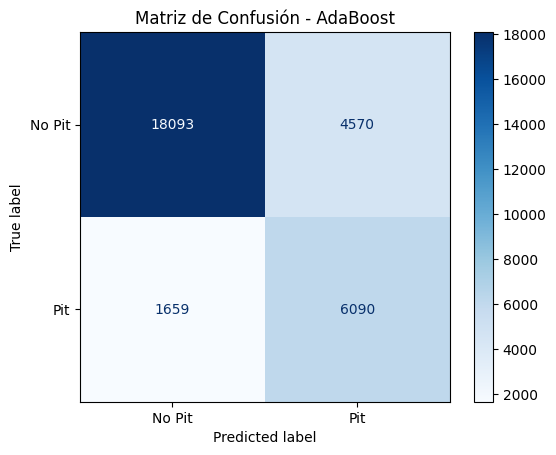

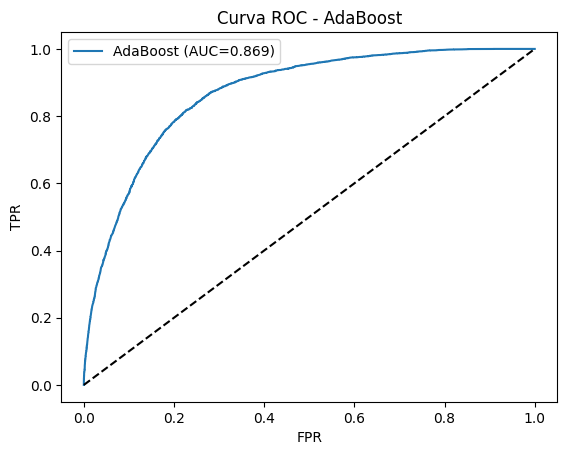

In [24]:
from sklearn.ensemble import AdaBoostClassifier

model_Ada = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=3),
    n_estimators=100,
    learning_rate=0.5,
    random_state=42
)

print('AdaBoost (base: Árbol de Decisión):')
model_Ada = evaluar_modelo('AdaBoost', model_Ada, X_train_norm_imputed, X_test_norm_imputed, Y_train, Y_test)

In [25]:
medidas

,Arbol,Knn,NN,SVM,SGD_SVM_Rapido,RandomForest,GradientBoosting,Bagging,AdaBoost
accuracy,0.799388,0.887413,0.831382,0.637314,0.728989,0.876529,0.845916,0.803466,0.795180
precision,0.577197,0.727703,0.618415,0.262281,0.473571,0.711323,0.674331,0.583052,0.571295
recall,0.795070,0.891857,0.883211,0.233579,0.570009,0.867467,0.764486,0.802684,0.785908
f1,0.668838,0.801461,0.727466,0.247099,0.517334,0.781673,0.716584,0.675463,0.661633
roc_auc,0.876478,0.954716,0.925008,0.548532,0.750648,0.949870,0.913385,0.880520,0.868987


# 5. Tabla comparativa de medidas de calidad

In [26]:
print('=== TABLA COMPARATIVA DE MEDIDAS DE CALIDAD ===')
print(medidas.round(4))

=== TABLA COMPARATIVA DE MEDIDAS DE CALIDAD ===
            Arbol     Knn      NN     SVM  SGD_SVM_Rapido  RandomForest  \
accuracy   0.7994  0.8874  0.8314  0.6373          0.7290        0.8765   
precision  0.5772  0.7277  0.6184  0.2623          0.4736        0.7113   
recall     0.7951  0.8919  0.8832  0.2336          0.5700        0.8675   
f1         0.6688  0.8015  0.7275  0.2471          0.5173        0.7817   
roc_auc    0.8765  0.9547  0.9250  0.5485          0.7506        0.9499   

           GradientBoosting  Bagging  AdaBoost  
accuracy             0.8459   0.8035    0.7952  
precision            0.6743   0.5831    0.5713  
recall               0.7645   0.8027    0.7859  
f1                   0.7166   0.6755    0.6616  
roc_auc              0.9134   0.8805    0.8690  


In [27]:
# Interpretación de las medidas
print('INTERPRETACIÓN:')
print('  accuracy  : proporción total de predicciones correctas')
print('  precision : de los pit stops predichos, cuántos son reales (evita falsas alarmas)')
print('  recall    : de los pit stops reales, cuántos detectamos (no perder pit stops)')
print('  f1        : media armónica entre precision y recall')
print('  roc_auc   : capacidad discriminante general (1.0 = perfecto, 0.5 = azar)')
print()
print('Para F1 el mejor modelo es:', medidas.loc['f1'].idxmax())
print('Para ROC-AUC el mejor modelo es:', medidas.loc['roc_auc'].idxmax())

INTERPRETACIÓN:
  accuracy  : proporción total de predicciones correctas
  precision : de los pit stops predichos, cuántos son reales (evita falsas alarmas)
  recall    : de los pit stops reales, cuántos detectamos (no perder pit stops)
  f1        : media armónica entre precision y recall
  roc_auc   : capacidad discriminante general (1.0 = perfecto, 0.5 = azar)

Para F1 el mejor modelo es: Knn
Para ROC-AUC el mejor modelo es: Knn


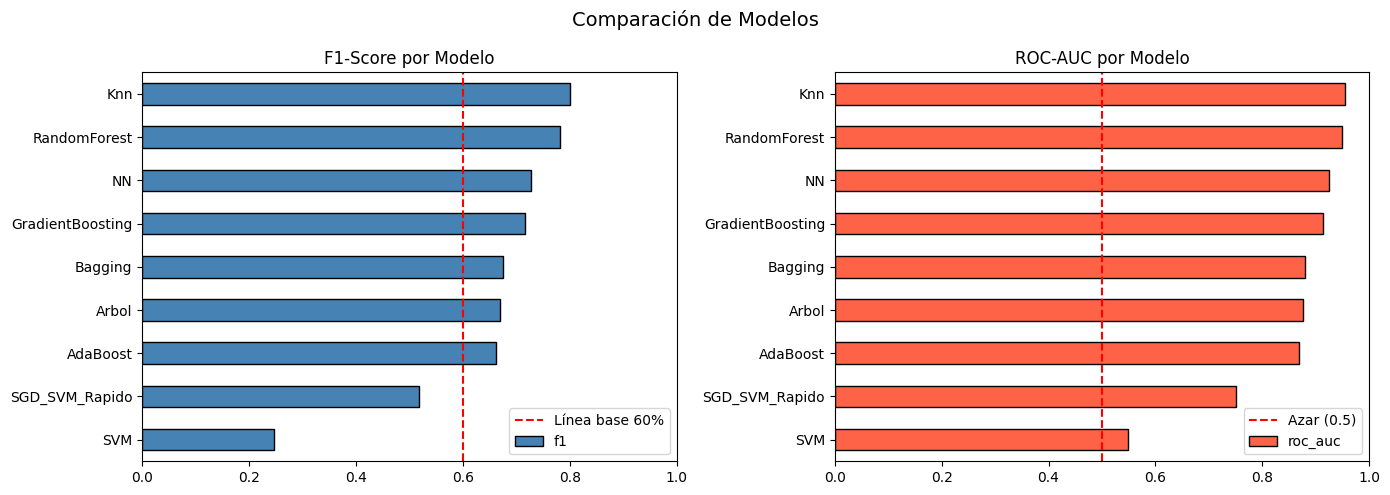

In [28]:
# Gráfica comparativa por métrica
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

medidas.loc['f1'].sort_values().plot(
    kind='barh', ax=axes[0], color='steelblue', edgecolor='black'
)
axes[0].set_title('F1-Score por Modelo'); axes[0].set_xlim(0, 1)
axes[0].axvline(0.6, color='red', linestyle='--', label='Línea base 60%')
axes[0].legend()

medidas.loc['roc_auc'].sort_values().plot(
    kind='barh', ax=axes[1], color='tomato', edgecolor='black'
)
axes[1].set_title('ROC-AUC por Modelo'); axes[1].set_xlim(0, 1)
axes[1].axvline(0.5, color='red', linestyle='--', label='Azar (0.5)')
axes[1].legend()

plt.suptitle('Comparación de Modelos', fontsize=14)
plt.tight_layout()
plt.show()

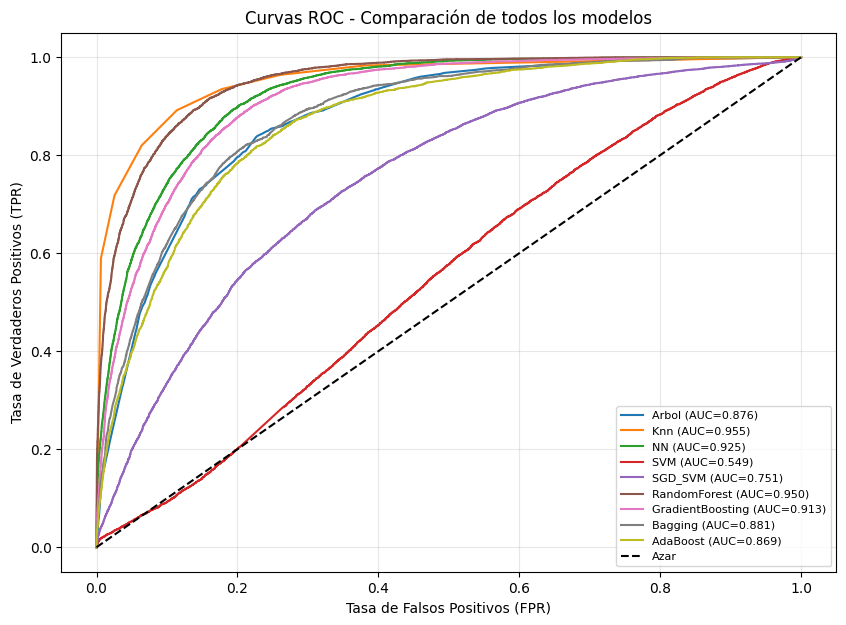

In [29]:
# Curvas ROC superpuestas de todos los modelos
# Reentrenamos para obtener las probabilidades
modelos_todos = {
    'Arbol':          (model_Tree, X_test),
    'Knn':            (model_Knn,  X_test_norm_imputed),
    'NN':             (model_NN,   X_test_norm_imputed),
    'SVM':            (model_svm,  X_test_norm_imputed),
    'SGD_SVM':        (model_SGD_SVM,  X_test_norm_imputed),
    'RandomForest':   (model_RF,   X_test),
    'GradientBoosting':(model_GB,  X_test_norm_imputed),
    'Bagging':        (model_Bag,  X_test),
    'AdaBoost':       (model_Ada,  X_test_norm_imputed),
}

plt.figure(figsize=(10, 7))
for nombre, (modelo, X_te) in modelos_todos.items():
    y_proba = modelo.predict_proba(X_te)[:, 1]
    fpr, tpr, _ = metrics.roc_curve(Y_test, y_proba)
    auc = metrics.roc_auc_score(Y_test, y_proba)
    plt.plot(fpr, tpr, label=f'{nombre} (AUC={auc:.3f})')

plt.plot([0,1],[0,1],'k--', label='Azar')
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curvas ROC - Comparación de todos los modelos')
plt.legend(loc='lower right', fontsize=8)
plt.grid(alpha=0.3)
plt.show()

# 6. Selección estadística: ANOVA + Tukey

In [30]:
from scipy.stats import f_oneway
from statsmodels.stats.multicomp import pairwise_tukeyhsd

nombres_cv = list(cv_scores.keys())
grupos_cv  = list(cv_scores.values())

# ANOVA de una vía
stat_f, p_anova = f_oneway(*grupos_cv)
print('=== ANOVA DE UNA VÍA ===')
print(f'Estadístico F : {stat_f:.4f}')
print(f'p-valor       : {p_anova:.6f}')
if p_anova < 0.05:
    print('-> Se rechaza H₀: existen diferencias significativas entre los modelos (p < 0.05)')
else:
    print('-> No se rechaza H₀: no hay diferencias significativas (p >= 0.05)')

=== ANOVA DE UNA VÍA ===
Estadístico F : 387.7056
p-valor       : 0.000000
-> Se rechaza H₀: existen diferencias significativas entre los modelos (p < 0.05)


In [31]:
# Test de Tukey HSD
all_scores = np.concatenate(grupos_cv)
all_labels = np.concatenate([[n]*len(g) for n, g in zip(nombres_cv, grupos_cv)])

tukey = pairwise_tukeyhsd(all_scores, all_labels, alpha=0.05)
print('=== TEST POST-HOC DE TUKEY HSD ===')
print(tukey)

=== TEST POST-HOC DE TUKEY HSD ===
          Multiple Comparison of Means - Tukey HSD, FWER=0.05           
     group1           group2      meandiff p-adj   lower   upper  reject
------------------------------------------------------------------------
        AdaBoost            Arbol   0.0275 0.1219 -0.0034  0.0584  False
        AdaBoost          Bagging   0.0201 0.4955 -0.0108  0.0511  False
        AdaBoost GradientBoosting   0.0735    0.0  0.0426  0.1044   True
        AdaBoost              Knn   0.0866    0.0  0.0557  0.1175   True
        AdaBoost               NN   0.0385 0.0047  0.0076  0.0694   True
        AdaBoost     RandomForest   0.0925    0.0  0.0616  0.1234   True
        AdaBoost   SGD_SVM_Rapido  -0.1436    0.0 -0.1745 -0.1127   True
        AdaBoost              SVM  -0.3207    0.0 -0.3516 -0.2898   True
           Arbol          Bagging  -0.0073 0.9977 -0.0382  0.0236  False
           Arbol GradientBoosting    0.046 0.0003  0.0151   0.077   True
           Arbol

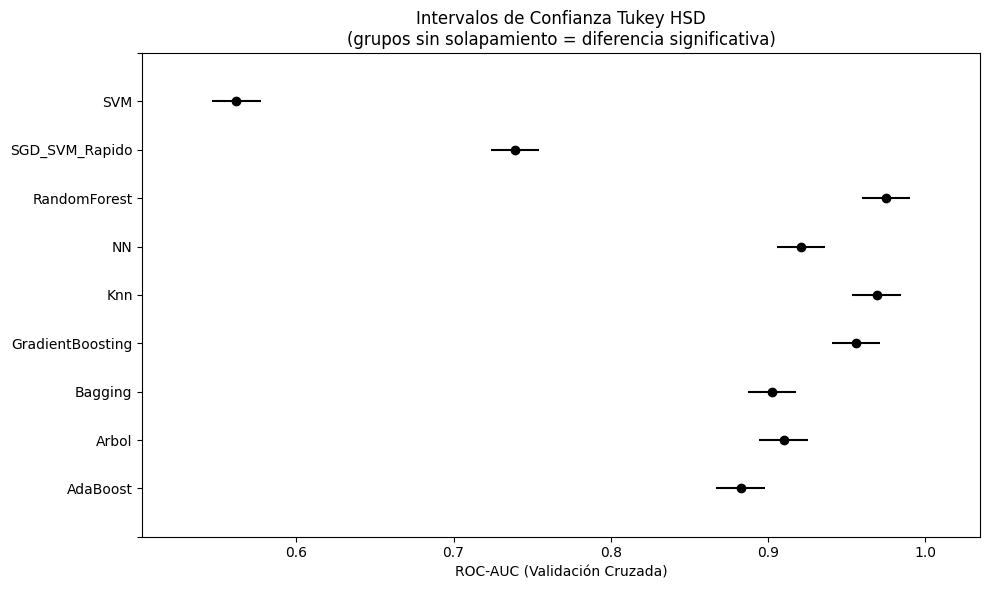

In [32]:
fig, ax = plt.subplots(figsize=(12, 5))
tukey.plot_simultaneous(ax=ax, xlabel='ROC-AUC (Validación Cruzada)')
ax.set_title('Intervalos de Confianza Tukey HSD\n(grupos sin solapamiento = diferencia significativa)')
plt.tight_layout()
plt.show()

In [33]:
# Seleccionamos el Top 3 por ROC-AUC en test
top3 = medidas.loc['roc_auc'].sort_values(ascending=False).head(3).index.tolist()
print('=== TOP 3 MODELOS SELECCIONADOS ===')
for i, nombre in enumerate(top3, 1):
    print(f'  {i}. {nombre}')
    print(f'     ROC-AUC={medidas.loc["roc_auc",nombre]:.4f}  F1={medidas.loc["f1",nombre]:.4f}  Recall={medidas.loc["recall",nombre]:.4f}')

=== TOP 3 MODELOS SELECCIONADOS ===
  1. Knn
     ROC-AUC=0.9547  F1=0.8015  Recall=0.8919
  2. RandomForest
     ROC-AUC=0.9499  F1=0.7817  Recall=0.8675
  3. NN
     ROC-AUC=0.9250  F1=0.7275  Recall=0.8832


# 7. Hiperparametrización del Top 3
## 7.1 GridSearchCV

In [34]:
from sklearn.model_selection import GridSearchCV

# Diccionario de configuraciones para GridSearch
# Ajustar según cuáles queden en el Top 3
config_gridsearch = {
    'Arbol': {
        'modelo': DecisionTreeClassifier(class_weight='balanced', random_state=42),
        'params': {
            'max_depth':        [5, 10, 15, None],
            'min_samples_leaf': [1, 3, 5, 10],
            'criterion':        ['gini', 'entropy']
        },
        'X_tr': X_train, 'X_te': X_test
    },
    'Knn': {
        'modelo': KNeighborsClassifier(),
        'params': {
            'n_neighbors': [3, 5, 7, 9, 11],
            'weights':     ['uniform', 'distance'],
            'metric':      ['euclidean', 'manhattan']
        },
        'X_tr': X_train_norm_imputed, 'X_te': X_test_norm_imputed
    },
    'NN': {
        'modelo': MLPClassifier(max_iter=200, random_state=42), # Reduced max_iter
        'params': {
            'hidden_layer_sizes': [(64,), (128, 64)], # Simplified architectures
            'activation':         ['relu'], # Fewer activation functions
            'learning_rate_init': [0.001] # Fewer learning rates
        },
        'X_tr': X_train_norm_imputed, 'X_te': X_test_norm_imputed
    },
    'SVM': {
        'modelo': SVC(probability=True, class_weight='balanced', random_state=42),
        'params': {
            'C':      [0.1, 1, 5, 10],
            'kernel': ['rbf', 'linear']
        },
        'X_tr': X_train_norm_imputed, 'X_te': X_test_norm_imputed
    },
    'SGD_SVM': {
        'modelo': SGDClassifier(
            loss='log_loss',
            class_weight='balanced',
            random_state=42,
            early_stopping=True,
            n_iter_no_change=5,
            tol=1e-3
        ),
        'params': {
            'alpha':     [0.0001, 0.001, 0.01],
            'max_iter':  [500, 1000, 1500],
            'penalty':   ['l1', 'l2', 'elasticnet']
        },
        'X_tr': X_train_norm_imputed, 'X_te': X_test_norm_imputed
    },
    'RandomForest': {
        'modelo': RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1),
        'params': {
            'n_estimators': [100, 200],
            'max_depth':    [10, 15, None],
            'min_samples_split': [2, 5]
        },
        'X_tr': X_train, 'X_te': X_test
    },
    'GradientBoosting': {
        'modelo': GradientBoostingClassifier(random_state=42),
        'params': {
            'n_estimators':  [100, 200],
            'learning_rate': [0.05, 0.1, 0.2],
            'max_depth':     [3, 5]
        },
        'X_tr': X_train_norm_imputed, 'X_te': X_test_norm_imputed
    },
    'Bagging': {
        'modelo': BaggingClassifier(
            estimator=DecisionTreeClassifier(class_weight='balanced'),
            random_state=42, n_jobs=-1
        ),
        'params': {
            'n_estimators':     [30, 50, 100],
            'max_samples':      [0.7, 1.0],
            'estimator__max_depth': [5, 10]
        },
        'X_tr': X_train, 'X_te': X_test
    },
    'AdaBoost': {
        'modelo': AdaBoostClassifier(
            estimator=DecisionTreeClassifier(max_depth=3),
            random_state=42
        ),
        'params': {
            'n_estimators':  [50, 100, 200],
            'learning_rate': [0.1, 0.5, 1.0]
        },
        'X_tr': X_train_norm_imputed, 'X_te': X_test_norm_imputed
    }
}

medidas_grid = pd.DataFrame(index=['accuracy','precision','recall','f1','roc_auc'])
modelos_optimizados = {}

print(f'Aplicando GridSearchCV al Top 3: {top3}\n')

for nombre in top3:
    cfg = config_gridsearch[nombre]
    gs = GridSearchCV(
        cfg['modelo'], cfg['params'],
        cv=StratifiedKFold(5, shuffle=True, random_state=42),
        scoring='roc_auc',
        n_jobs=-1, verbose=0
    )
    gs.fit(cfg['X_tr'], Y_train)

    Y_pred  = gs.best_estimator_.predict(cfg['X_te'])
    Y_proba = gs.best_estimator_.predict_proba(cfg['X_te'])[:, 1]

    medidas_grid[nombre + '_grid'] = [
        metrics.accuracy_score(Y_test, Y_pred),
        metrics.precision_score(Y_test, Y_pred, zero_division=0),
        metrics.recall_score(Y_test, Y_pred, zero_division=0),
        metrics.f1_score(Y_test, Y_pred, zero_division=0),
        metrics.roc_auc_score(Y_test, Y_proba)
    ]
    modelos_optimizados[nombre] = {
        'estimator': gs.best_estimator_,
        'params':    gs.best_params_,
        'cv_auc':    gs.best_score_,
        'X_tr': cfg['X_tr'],
        'X_te': cfg['X_te']
    }
    print(f'   {nombre}')
    print(f'     Mejores params: {gs.best_params_}')
    print(f'     CV AUC: {gs.best_score_:.4f} | Test AUC: {medidas_grid[nombre+"_grid"]["roc_auc"]:.4f}\n')


Aplicando GridSearchCV al Top 3: ['Knn', 'RandomForest', 'NN']

   Knn
     Mejores params: {'metric': 'manhattan', 'n_neighbors': 7, 'weights': 'distance'}
     CV AUC: 0.9805 | Test AUC: 0.9702

   RandomForest
     Mejores params: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
     CV AUC: 0.9917 | Test AUC: 0.9778

   NN
     Mejores params: {'activation': 'relu', 'hidden_layer_sizes': (128, 64), 'learning_rate_init': 0.001}
     CV AUC: 0.9454 | Test AUC: 0.9429



In [35]:
print('Medidas después de GridSearchCV:')
print(medidas_grid.round(4))

Medidas después de GridSearchCV:
           Knn_grid  RandomForest_grid  NN_grid
accuracy     0.9215             0.9369   0.8777
precision    0.8100             0.8745   0.7248
recall       0.9040             0.8783   0.8382
f1           0.8544             0.8764   0.7774
roc_auc      0.9702             0.9778   0.9429


## 7.2 Optimización Bayesiana (BayesSearchCV)

In [36]:
pip install scikit-optimize

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 3.8 MB/s eta 0:00:00


In [37]:
from skopt import BayesSearchCV
from skopt.space import Real, Integer, Categorical

# Aplicamos Optimización Bayesiana al mejor del GridSearch
mejor_grid = medidas_grid.loc['roc_auc'].idxmax().replace('_grid', '')
print(f'Aplicando Optimización Bayesiana al mejor del GridSearch: {mejor_grid}')

# Espacios de búsqueda bayesiana por modelo
espacios_bayes = {
    'Arbol': (
        DecisionTreeClassifier(class_weight='balanced', random_state=42),
        {
            'max_depth':        Integer(3, 20),
            'min_samples_leaf': Integer(1, 15),
            'criterion':        Categorical(['gini', 'entropy'])
        }
    ),
    'Knn': (
        KNeighborsClassifier(),
        {
            'n_neighbors': Integer(3, 20),
            'weights':     Categorical(['uniform', 'distance'])
        }
    ),
    'NN': (
        MLPClassifier(max_iter=500, random_state=42),
        {
            'learning_rate_init': Real(0.0001, 0.1, prior='log-uniform'),
            'momentum':           Real(0.5, 0.99)
        }
    ),
    'SVM': (
        SVC(probability=True, class_weight='balanced', random_state=42),
        {
            'C':     Real(0.01, 20.0, prior='log-uniform'),
            'kernel': Categorical(['rbf', 'linear'])
        }
    ),
    'RandomForest': (
        RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1),
        {
            'n_estimators':      Integer(50, 300),
            'max_depth':         Integer(5, 30),
            'min_samples_split': Integer(2, 10),
            'min_samples_leaf':  Integer(1, 5)
        }
    ),
    'GradientBoosting': (
        GradientBoostingClassifier(random_state=42),
        {
            'n_estimators':  Integer(50, 300),
            'learning_rate': Real(0.01, 0.3, prior='log-uniform'),
            'max_depth':     Integer(2, 8)
        }
    ),
    'Bagging': (
        BaggingClassifier(
            estimator=DecisionTreeClassifier(class_weight='balanced'),
            random_state=42, n_jobs=-1
        ),
        {
            'n_estimators': Integer(30, 150),
            'max_samples':  Real(0.5, 1.0)
        }
    ),
    'AdaBoost': (
        AdaBoostClassifier(
            estimator=DecisionTreeClassifier(max_depth=3),
            random_state=42
        ),
        {
            'n_estimators':  Integer(50, 250),
            'learning_rate': Real(0.01, 2.0, prior='log-uniform')
        }
    )
}

modelo_bayes_base, espacio_bayes = espacios_bayes[mejor_grid]
cfg_mejor = modelos_optimizados[mejor_grid]

bayes_search = BayesSearchCV(
    modelo_bayes_base,
    espacio_bayes,
    n_iter=30,
    cv=StratifiedKFold(5, shuffle=True, random_state=42),
    scoring='roc_auc',
    n_jobs=-1,
    random_state=42,
    verbose=0
)
bayes_search.fit(cfg_mejor['X_tr'], Y_train)

Y_pred_b  = bayes_search.best_estimator_.predict(cfg_mejor['X_te'])
Y_proba_b = bayes_search.best_estimator_.predict_proba(cfg_mejor['X_te'])[:, 1]

print(f'\nOptimización Bayesiana completada ')
print(f'  Mejores parámetros: {dict(bayes_search.best_params_)}')
print(f'  CV ROC-AUC : {bayes_search.best_score_:.4f}')
print(f'  Test ROC-AUC: {metrics.roc_auc_score(Y_test, Y_proba_b):.4f}')
print(f'  Test F1     : {metrics.f1_score(Y_test, Y_pred_b, zero_division=0):.4f}')
print(f'  Test Recall : {metrics.recall_score(Y_test, Y_pred_b, zero_division=0):.4f}')

Aplicando Optimización Bayesiana al mejor del GridSearch: RandomForest

Optimización Bayesiana completada 
  Mejores parámetros: {'max_depth': 30, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
  CV ROC-AUC : 0.9917
  Test ROC-AUC: 0.9776
  Test F1     : 0.8732
  Test Recall : 0.8752


# 8. Guardamos el modelo final

In [38]:
# Comparamos GridSearch vs Bayesiana para elegir el mejor definitivo
auc_grid  = medidas_grid.loc['roc_auc', mejor_grid + '_grid']
auc_bayes = metrics.roc_auc_score(Y_test, Y_proba_b)

print(f'GridSearchCV  - Test ROC-AUC: {auc_grid:.4f}')
print(f'Opt. Bayesiana - Test ROC-AUC: {auc_bayes:.4f}')

if auc_bayes >= auc_grid:
    modelo_seleccionado = bayes_search.best_estimator_
    print('-> Se selecciona el modelo de Optimización Bayesiana')
else:
    modelo_seleccionado = modelos_optimizados[mejor_grid]['estimator']
    print('-> Se selecciona el modelo de GridSearchCV')

GridSearchCV  - Test ROC-AUC: 0.9778
Opt. Bayesiana - Test ROC-AUC: 0.9776
-> Se selecciona el modelo de GridSearchCV


In [39]:
# Entrenamos el modelo final con el 100% de los datos
# Preparamos X e Y completos
import pandas as pd
data_full = pd.read_csv('f1_strategy_dataset_v4.csv')

cols_modelo = [
    'Compound', 'Stint', 'TyreLife', 'Position', 'LapTime (s)',
    'LapTime_Delta', 'Cumulative_Degradation', 'RaceProgress',
    'Normalized_TyreLife', 'Position_Change', 'PitNextLap'
]
data_full = data_full[cols_modelo].copy()
data_full['Compound'] = data_full['Compound'].map(compound_map)
mediana_ref = data_full.groupby(data_full.index // 60)['LapTime (s)'].transform('median')
mask_sc = data_full['LapTime (s)'] > 150
data_full.loc[mask_sc, 'LapTime (s)'] = mediana_ref[mask_sc]

X_full = data_full.drop('PitNextLap', axis=1)
Y_full = data_full['PitNextLap']

# Normalizar si el modelo lo requiere
necesita_norm = mejor_grid in ['Knn', 'NN', 'SVM']
if necesita_norm:
    X_full_proc = X_full.copy()
    X_full_proc[variables_numericas] = min_max_scaler.transform(X_full[variables_numericas])
else:
    X_full_proc = X_full.copy()

modelo_seleccionado.fit(X_full_proc, Y_full)
print('Modelo entrenado con el 100% de los datos ')

Modelo entrenado con el 100% de los datos 


In [42]:
from sklearn.metrics import accuracy_score, roc_auc_score

# Determine which data to use based on 'necesita_norm' for the selected model
if necesita_norm:
    X_train_final = X_train_norm_imputed
    X_test_final = X_test_norm_imputed
else:
    X_train_final = X_train
    X_test_final = X_test

# Predicción entrenamiento
y_train_pred = modelo_seleccionado.predict(X_train_final)

# Predicción prueba
y_test_pred = modelo_seleccionado.predict(X_test_final)

# Accuracy
train_acc = accuracy_score(Y_train, y_train_pred)
test_acc = accuracy_score(Y_test, y_test_pred)

print("Accuracy Train:", train_acc)
print("Accuracy Test :", test_acc)

# ROC AUC
train_auc = roc_auc_score(Y_train, modelo_seleccionado.predict_proba(X_train_final)[:,1])
test_auc = roc_auc_score(Y_test, modelo_seleccionado.predict_proba(X_test_final)[:,1])

print("ROC-AUC Train:", train_auc)
print("ROC-AUC Test :", test_auc)

Accuracy Train: 0.9577998827511867
Accuracy Test : 0.9999342364855978
ROC-AUC Train: 0.9964817933397793
ROC-AUC Test : 0.9999999316689355


In [40]:
# Guardamos el modelo con pickle
variables_numericas = [
    'Stint', 'TyreLife', 'Position', 'LapTime (s)',
    'LapTime_Delta', 'Cumulative_Degradation', 'RaceProgress',
    'Normalized_TyreLife', 'Position_Change', 'Compound'
]

filename = 'modelo-f1.pkl'
pickle.dump(
    [modelo_seleccionado, min_max_scaler, variables, compound_map, necesita_norm, mejor_grid],
    open(filename, 'wb')
)

print(f'Modelo guardado en: {filename} ')
print(f'Tipo de modelo: {type(modelo_seleccionado).__name__}')
print(f'Requiere normalización: {necesita_norm}')
print(medidas.round(4))

Modelo guardado en: modelo-f1.pkl 
Tipo de modelo: RandomForestClassifier
Requiere normalización: False
            Arbol     Knn      NN     SVM  SGD_SVM_Rapido  RandomForest  \
accuracy   0.7994  0.8874  0.8314  0.6373          0.7290        0.8765   
precision  0.5772  0.7277  0.6184  0.2623          0.4736        0.7113   
recall     0.7951  0.8919  0.8832  0.2336          0.5700        0.8675   
f1         0.6688  0.8015  0.7275  0.2471          0.5173        0.7817   
roc_auc    0.8765  0.9547  0.9250  0.5485          0.7506        0.9499   

           GradientBoosting  Bagging  AdaBoost  
accuracy             0.8459   0.8035    0.7952  
precision            0.6743   0.5831    0.5713  
recall               0.7645   0.8027    0.7859  
f1                   0.7166   0.6755    0.6616  
roc_auc              0.9134   0.8805    0.8690  
